In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [22]:
export_hwannier("wannier", spin=Val('u'))
export_hwannier("wannier", spin=Val('d'))
export_momentum("wannier", spin=Val('u'))
export_momentum("wannier", spin=Val('d'));
export_heph("wannier", spin=Val('u'));
export_heph("wannier", spin=Val('d'));

In [3]:
kpoints = bandstructkpoints2q(kpointsfile="../bandstruct.kpoints", interpolate=5);

In [4]:
HwannierUp, cell_mapUp = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt")
HwannierDn, cell_mapDn = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt");
Pwannier = pwannier("wannierUp");
Heph, celleph_map = hephwannier("wannierUp"), np.loadtxt("wannierUp.mapeph.txt");
lattice_vectors = loadlattice("wannier.out");

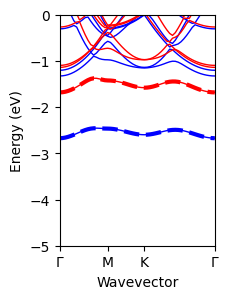

(0.0, 55.0)

In [5]:
figure(figsize=(2, 3))
plot_bands(HwannierUp, cell_mapUp, linewidth=3, color="blue", linestyle="dashed")
plot_bands(HwannierDn, cell_mapDn, linewidth=3, color="red", linestyle="dashed")
plot_bands("../BN33BC.bands.eigenvals", spin=2, linewidth=1)
ylim(-5, 0)
label_plots()

In [9]:
force_matrix, cellph_map = phonon_force_matrix("../../BN33BC_Buckled/phonon");
phonon_bands_bn33bc = phonon_dispersion(force_matrix, cellph_map, return_negative=true);

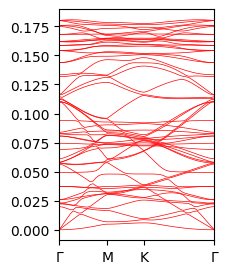

(0.0, 55.0)

In [10]:
figure(figsize=(2, 3))
plot(phonon_bands_bn33bc, color="red", linewidth=0.5)
label_plots()

In [11]:
x, y = density_of_states(HwannierUp, cell_mapUp, mesh=20, num_blocks=1000, monte_carlo=true, histogram_width=1000)

([-3.6728777575016185, -3.671877574206857, -3.670877390912095, -3.6698772076173336, -3.6688770243225717, -3.66787684102781, -3.6668766577330487, -3.665876474438287, -3.6648762911435253, -3.663876107848764  …  -1.46647340925742, -1.4654732259626586, -1.4644730426678967, -1.4634728593731352, -1.4624726760783737, -1.4614724927836118, -1.4604723094888503, -1.4594721261940884, -1.458471942899327, -1.4574717596045654], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

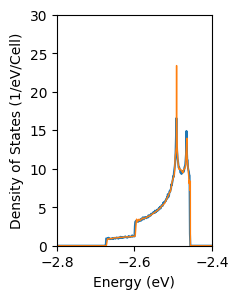

(0.0, 30.0)

In [12]:
figure(figsize=(2, 3))
plot(x, y)
density_of_states("../DOS/BN33BC.dosUp", linewidth=1)
xlim(-2.8, -2.4)
ylim(0, 30)

In [13]:
e, n = find_chemical_potential(x, y);

In [14]:
# The DOS at the fermi level
#y[argmin(abs.(n .- 0.5))]
x[argmin(abs.(n .- 0.5))]


-2.5056638525147736

In [23]:
polarizations = []
for (i,k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    push!(polarizations, ImΠ(HwannierUp, cell_mapUp, lattice_vectors, k, -2.5, Val(2), histogram_width=1000, mesh=100, num_blocks=10, monte_carlo=true))
end

1
[0.0, 0.0, 0.0]
2
[0.0058823529412, 0.0, 0.0]
3
[0.0117647058824, 0.0, 0.0]
4
[0.0176470588236, 0.0, 0.0]
5
[0.0235294117648, 0.0, 0.0]
6
[0.029411764706, 0.0, 0.0]
7
[0.0352941176472, 0.0, 0.0]
8
[0.0411764705884, 0.0, 0.0]
9
[0.0470588235296, 0.0, 0.0]
10
[0.0529411764708, 0.0, 0.0]
11
[0.058823529412, 0.0, 0.0]
12
[0.0647058823532, 0.0, 0.0]
13
[0.0705882352944, 0.0, 0.0]
14
[0.0764705882356, 0.0, 0.0]
15
[0.0823529411768, 0.0, 0.0]
16
[0.088235294118, 0.0, 0.0]
17
[0.0941176470592, 0.0, 0.0]
18
[0.1000000000004, 0.0, 0.0]
19
[0.1058823529416, 0.0, 0.0]
20
[0.1117647058828, 0.0, 0.0]
21
[0.117647058824, 0.0, 0.0]
22
[0.123529411765, 0.0, 0.0]
23
[0.129411764706, 0.0, 0.0]
24
[0.135294117647, 0.0, 0.0]
25
[0.14117647058799998, 0.0, 0.0]
26
[0.147058823529, 0.0, 0.0]
27
[0.1529411764702, 0.0, 0.0]
28
[0.1588235294114, 0.0, 0.0]
29
[0.1647058823526, 0.0, 0.0]
30
[0.1705882352938, 0.0, 0.0]
31
[0.176470588235, 0.0, 0.0]
32
[0.1823529411762, 0.0, 0.0]
33
[0.1882352941174, 0.0, 0.0]
34


In [24]:
energies = range(0, 100, length=100000)
energies = collect(energies)
epsilons_default = zeros(50, 300)
for (i, k) in enumerate(kpoints[1:50])
    i == 1 && continue
    for (j, ω) in enumerate(range(0.05, 1, length=300))
        epsilons_default[i, j] = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=10), Val(2), Val(:default), limit=20, δ=0.001, normalized=true))
    end
end

In [30]:
energies = range(0, 100, length=100000)
energies = collect(energies)
epsilons_scipy = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    i == 1 && continue
    for (j, ω) in enumerate(range(0.05, 1, length=100))
       epsilons_scipy[i, j] = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=10), Val(2), Val(:scipy), limit=50, δ=0.001, normalized=true))
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [40]:
energies = range(0, 100, length=100000)
energies = collect(energies)
epsilons_quadgk = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    i == 1 && continue
    for (j, ω) in enumerate(range(0.05, 1, length=100)[1:100])
    x = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=10), Val(2), Val(:quadgk), rtol=1e-7, atol=1e-7, δ=0.01, normalized=true))
     epsilons_quadgk[i, j] = x
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [33]:
plasmon_scipy = [range(0.05, 1, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_scipy[2:50, :])))];
plasmon_scipy = [0, plasmon_scipy...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_scipy);
plasmon_scipy = smooth(plasmon_scipy, win_len=10);
plasmon_scipy[1] = 0;

In [43]:
plasmon_quadgk = [range(0.05, 1, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_quadgk[2:50, :])))];
plasmon_quadgk = [0, plasmon_quadgk...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_quadgk);
plasmon_quadgk = smooth(plasmon_quadgk, win_len=10);
plasmon_quadgk[1] = 0;

In [44]:
plasmon_default = [range(0.05, 1, length=300)[argmin(x)] for x in eachrow(log.(abs.(epsilons_default[2:50, :])))];
plasmon_default = [0, plasmon_default...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_default);
plasmon_default = smooth(plasmon_default, win_len=10);
plasmon_default[1] = 0;

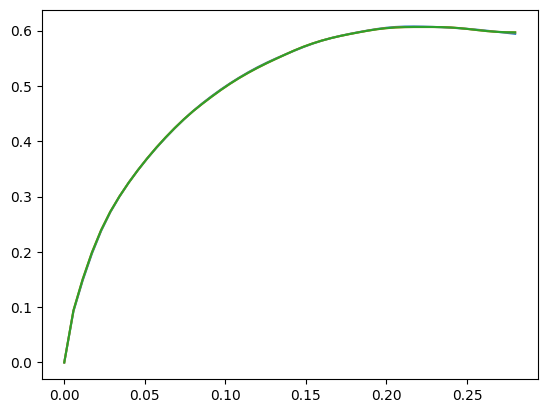

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f189be01250>

In [45]:
plot(qs, plasmon_default)
plot(qs, plasmon_scipy)
plot(qs, plasmon_quadgk)

In [46]:
np.savetxt("plasmon.txt", hcat(qs, plasmon_default, plasmon_scipy, plasmon_quadgk), header="qs, default, scipy, quadgk")

In [21]:
tau =  JJDFTX.τ_allen(HwannierUp, cell_mapUp, Pwannier, force_matrix, cellph_map, Heph, celleph_map, collect(0.01:0.01:1), -2.5, Val(2); 
mesh=3, supplydos=7.675, num_blocks=1000, fracroom=1, histogram_width=100)

DOS at Fermi Energy is: 7.675
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98

Block: 753
Block: 754
Block: 755
Block: 756
Block: 757
Block: 758
Block: 759
Block: 760
Block: 761
Block: 762
Block: 763
Block: 764
Block: 765
Block: 766
Block: 767
Block: 768
Block: 769
Block: 770
Block: 771
Block: 772
Block: 773
Block: 774
Block: 775
Block: 776
Block: 777
Block: 778
Block: 779
Block: 780
Block: 781
Block: 782
Block: 783
Block: 784
Block: 785
Block: 786
Block: 787
Block: 788
Block: 789
Block: 790
Block: 791
Block: 792
Block: 793
Block: 794
Block: 795
Block: 796
Block: 797
Block: 798
Block: 799
Block: 800
Block: 801
Block: 802
Block: 803
Block: 804
Block: 805
Block: 806
Block: 807
Block: 808
Block: 809
Block: 810
Block: 811
Block: 812
Block: 813
Block: 814
Block: 815
Block: 816
Block: 817
Block: 818
Block: 819
Block: 820
Block: 821
Block: 822
Block: 823
Block: 824
Block: 825
Block: 826
Block: 827
Block: 828
Block: 829
Block: 830
Block: 831
Block: 832
Block: 833
Block: 834
Block: 835
Block: 836
Block: 837
Block: 838
Block: 839
Block: 840
Block: 841
Block: 842
Block: 843

100-element Vector{Float64}:
  5.413293799224331
  8.07829893948494
  9.346689418145125
  9.743300202959002
 10.031040629226187
 10.097116908915535
 10.300122075284676
 10.431588641612874
 10.416709131822413
 10.28299067321872
 10.379863751850202
 10.026463716987346
  9.651204299450631
  ⋮
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf

In [24]:
omegas = 0.01:0.01:1;
np.savetxt("tau_allen.txt", hcat(omegas, tau))

In [25]:
omegas, tau_allen = [col for col in eachcol(np.loadtxt("tau_allen.txt"))]
omegas, taus = [col for col in eachcol(np.loadtxt("tau.txt"))]

2-element Vector{SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}:
 [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1  …  0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0]
 [6.096122481484745, 5.111008246609531, 4.310711069455848, 3.6582885792543727, 3.124174613960432, 2.6848037497312425, 2.3214525245146826, 2.019278641286177, 1.7665342823184182, 1.553928100600564  …  0.17064120355817372, 0.17008345690143414, 0.16953972569072356, 0.1690094881961387, 0.1684922482658403, 0.16798753377756126, 0.1674948952012612, 0.16701390426373508, 0.16654415270683173, 0.16608525113172107]

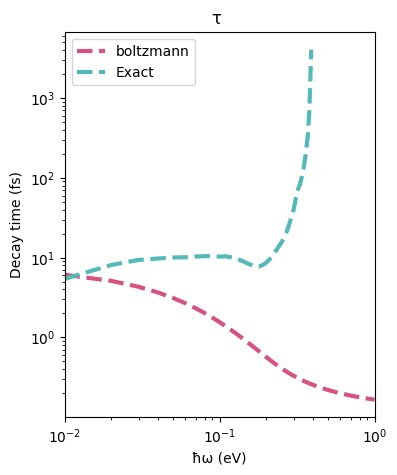

(0.01, 1)

In [44]:
color_allen = "#54BAB9"
color_taus = "#D75281"

figure(figsize=(4, 5))
title("τ ")
ylabel("Decay time (fs)")
xlabel("ħω (eV)")

loglog(omegas, taus, color=color_taus, linewidth=3, label="boltzmann", linestyle="dashed")
loglog(omegas, tau_allen, color=color_allen, linewidth=3, label="Exact", linestyle="dashed")
legend()
xlim(0.01, 1)